In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, f1_score,
    confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/sample_data/Teen_Mental_Health_Dataset.csv")
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print('Shape:', df.shape)
print(df.head(20).to_string())

Shape: (1200, 13)
    age  gender  daily_social_media_hours platform_usage  sleep_hours  screen_time_before_sleep  academic_performance  physical_activity social_interaction_level  stress_level  anxiety_level  addiction_level  depression_label
0    14    male                       7.9      Instagram          7.4                       2.9                  3.01                1.5                      low             2              2                1                 0
1    19  female                       1.9         TikTok          8.0                       2.9                  3.22                0.8                     high             8              1               10                 0
2    17  female                       1.3      Instagram          7.6                       0.5                  3.92                0.0                     high             2              4                2                 0
3    15    male                       7.4         TikTok          6.9         

In [ ]:
print(df.dtypes)

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB
None

In [ ]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

print(df.describe())
print()
print('Class distribution:')
print(df['depression_label'].value_counts())
print()
print('Class distribution (%):')
print(df['depression_label'].value_counts(normalize=True) * 100)

               age  daily_social_media_hours  sleep_hours  screen_time_before_sleep  academic_performance  physical_activity  stress_level  anxiety_level  addiction_level  depression_label
count  1200.000000               1200.000000  1200.000000               1200.000000           1200.000000        1200.000000   1200.000000    1200.000000      1200.000000       1200.000000
mean     15.928333                  4.536667     6.449417                  1.740333              2.990383           1.014500      5.445833       5.636667         5.565000          0.025833
std       2.021947                  2.029599     1.442677                  0.716660              0.576758           0.582185      2.903290       2.859453         2.830627          0.158704
min      13.000000                  1.000000     4.000000                  0.500000              2.000000           0.000000      1.000000       1.000000         1.000000          0.000000
25%      14.000000                  2.800000     5.2000

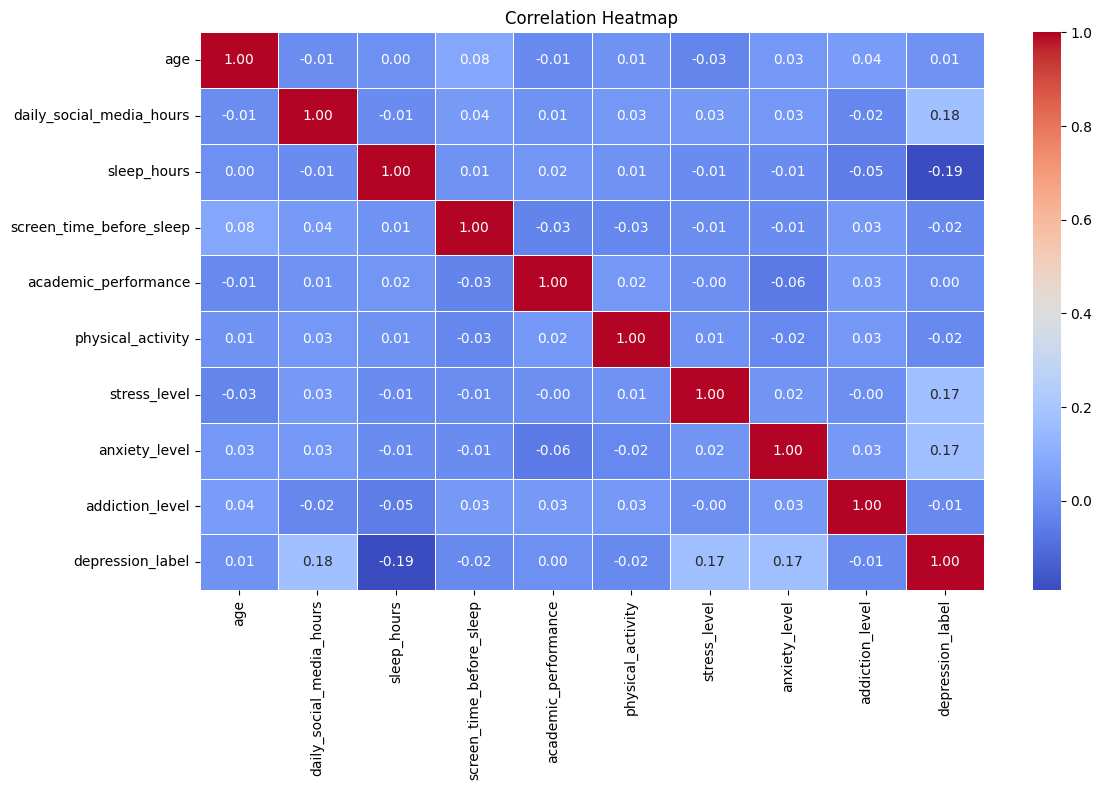

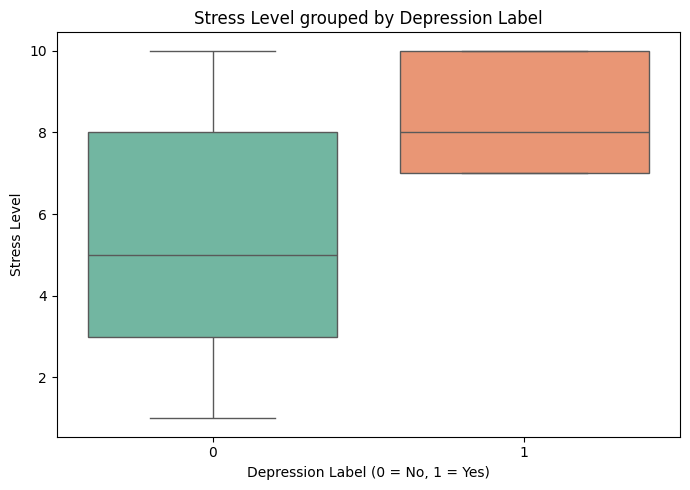

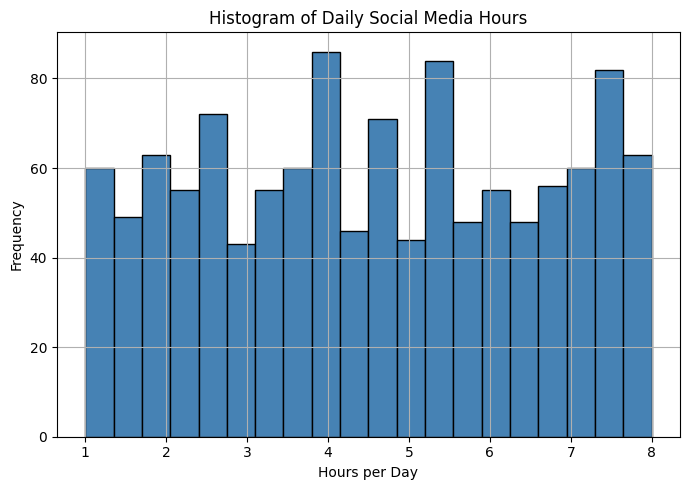

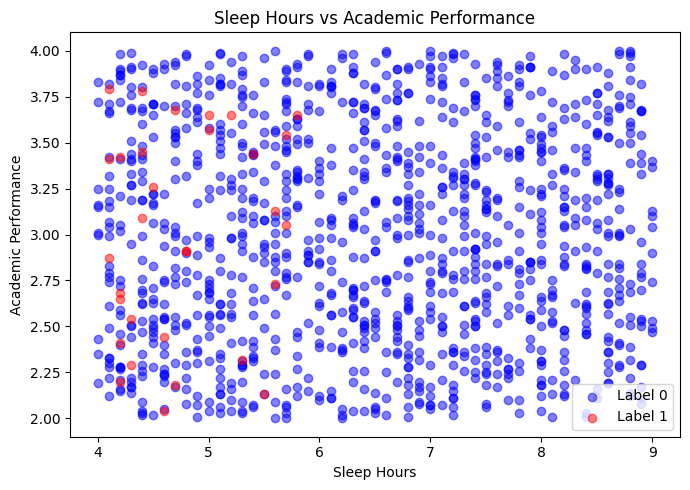

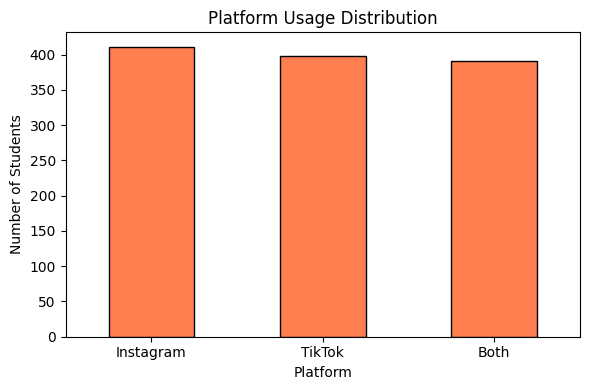

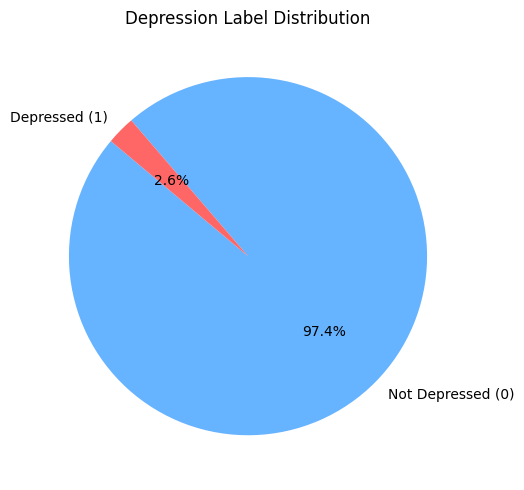

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Figure 2: Boxplot (REQUIRED)
plt.figure(figsize=(7, 5))
sns.boxplot(x='depression_label', y='stress_level', data=df, palette='Set2')
plt.title('Stress Level grouped by Depression Label')
plt.xlabel('Depression Label (0 = No, 1 = Yes)')
plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

# Figure 3: Histogram
plt.figure(figsize=(7, 5))
df['daily_social_media_hours'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Histogram of Daily Social Media Hours')
plt.xlabel('Hours per Day')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Figure 4: Scatter Plot
plt.figure(figsize=(7, 5))
for label, colour in zip([0, 1], ['blue', 'red']):
    subset = df[df['depression_label'] == label]
    plt.scatter(subset['sleep_hours'], subset['academic_performance'],
                label=f'Label {label}', alpha=0.5, color=colour)
plt.title('Sleep Hours vs Academic Performance')
plt.xlabel('Sleep Hours')
plt.ylabel('Academic Performance')
plt.legend()
plt.tight_layout()
plt.show()

# Figure 5: Bar Chart
plt.figure(figsize=(6, 4))
df['platform_usage'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Platform Usage Distribution')
plt.xlabel('Platform')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Figure 6: Pie Chart
plt.figure(figsize=(6, 5))
counts = df['depression_label'].value_counts()
plt.pie(counts, labels=['Not Depressed (0)', 'Depressed (1)'],
        autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#ff6666'])
plt.title('Depression Label Distribution')
plt.tight_layout()
plt.show()

In [ ]:
# Block 8 — Encoding Categorical Columns
le = LabelEncoder()
df['gender_enc']   = le.fit_transform(df['gender'])
df['social_enc']   = df['social_interaction_level'].map(
                         {'low': 0, 'medium': 1, 'high': 2})
df['platform_enc'] = df['platform_usage'].map(
                         {'Instagram': 0, 'TikTok': 1, 'Both': 2})
print('Encoding done.')
print(df[['gender','gender_enc','social_interaction_level',
          'social_enc','platform_usage','platform_enc']].head(5))

Encoding done.
   gender  gender_enc social_interaction_level  social_enc platform_usage  platform_enc
0    male           1                      low           0      Instagram             0
1  female           0                     high           2         TikTok             1
2  female           0                     high           2      Instagram             0
3    male           1                   medium           1         TikTok             1
4  female           0                   medium           1           Both             2


In [ ]:
# Block 9 — Feature and Target Separation
feature_cols = ['age', 'gender_enc', 'daily_social_media_hours',
                'platform_enc', 'sleep_hours', 'screen_time_before_sleep',
                'academic_performance', 'physical_activity', 'social_enc',
                'stress_level', 'anxiety_level', 'addiction_level']

X = df[feature_cols]
y = df['depression_label']
print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (1200, 12)
Target shape: (1200,)


In [ ]:
# Block 10 — Train-Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)
print('y_train distribution:')
print(y_train.value_counts())
print('y_test distribution:')
print(y_test.value_counts())

Training set size: (960, 12)
Test set size:     (240, 12)
y_train distribution:
depression_label
0    935
1     25
Name: count, dtype: int64
y_test distribution:
depression_label
0    234
1      6
Name: count, dtype: int64


In [ ]:
# Block 11 — Feature Scaling with StandardScaler
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling complete.')

Scaling complete.


In [ ]:
# Block 12 — Logistic Regression
lr_model  = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)

print('=== Logistic Regression Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr, average="weighted", zero_division=0):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_lr))
print('Classification Report:')
print(classification_report(y_test, y_pred_lr, zero_division=0))

=== Logistic Regression Results ===
Accuracy : 0.9875
F1 Score : 0.9855
Confusion Matrix:
[[234   0]
 [  3   3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



In [ ]:
# Block 13 — Random Forest
rf_model  = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print('=== Random Forest Results ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_rf, average="weighted", zero_division=0):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('Classification Report:')
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Random Forest Results ===
Accuracy : 0.9750
F1 Score : 0.9627
Confusion Matrix:
[[234   0]
 [  6   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



In [ ]:
# Block 14 — K-Nearest Neighbors (k=7)
knn_model  = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_sc, y_train)
y_pred_knn = knn_model.predict(X_test_sc)

print('=== KNN Results (k=7) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_knn, average="weighted", zero_division=0):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_knn))
print('Classification Report:')
print(classification_report(y_test, y_pred_knn, zero_division=0))

=== KNN Results (k=7) ===
Accuracy : 0.9750
F1 Score : 0.9627
Confusion Matrix:
[[234   0]
 [  6   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       234
           1       0.00      0.00      0.00         6

    accuracy                           0.97       240
   macro avg       0.49      0.50      0.49       240
weighted avg       0.95      0.97      0.96       240



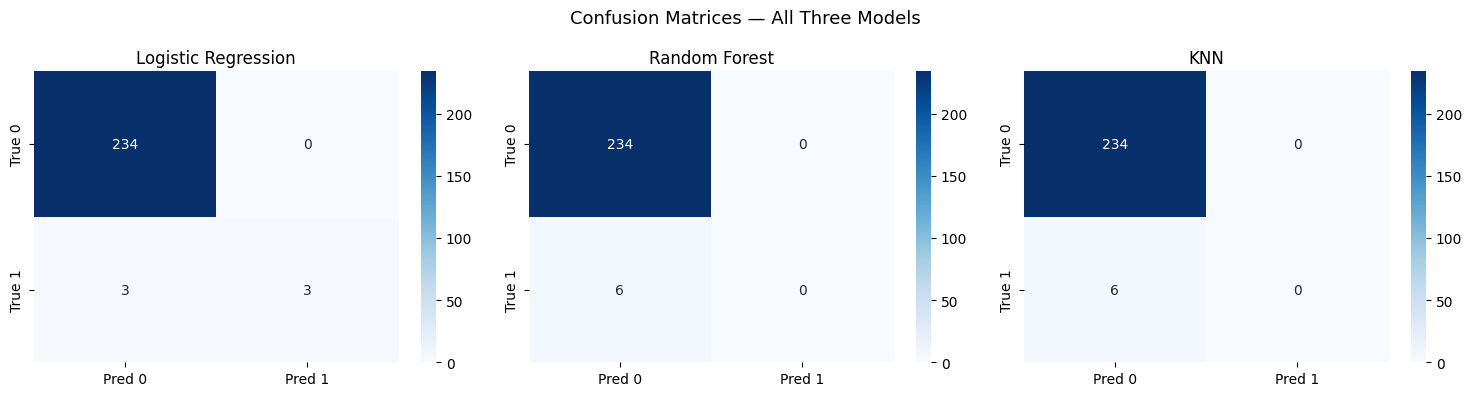

In [ ]:
# Block 15 — Confusion Matrix Heatmaps for All Three Models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [('Logistic Regression', y_pred_lr),
          ('Random Forest',       y_pred_rf),
          ('KNN',           y_pred_knn)]

for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(name)

plt.suptitle('Confusion Matrices — All Three Models', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Block 16 — Model Comparison Summary
results = {
    'Model':    ['Logistic Regression', 'Random Forest', 'KNN (k=7)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_knn)],
    'F1 Score': [f1_score(y_test, y_pred_lr, average='weighted', zero_division=0),
                 f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
                 f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)]
}
summary_df = pd.DataFrame(results)
print('=== Model Comparison Summary ===')
print(summary_df.to_string(index=False))

=== Model Comparison Summary ===
              Model  Accuracy  F1 Score
Logistic Regression    0.9875  0.985456
      Random Forest    0.9750  0.962658
          KNN (k=7)    0.9750  0.962658
